### **Задание**: **_cпам-фильтрация для текстовых сообщений_**
* **Набор данных**: SMS Spam Collection на Kaggle.
* **Предварительная обработка**: векторизация текста, масштабирование,
разделение данных на обучающие и тестовые.
* **Модели**: логистическая регрессия, SVM, случайный лес, градиентный
бустинг.
* **Сравнение моделей**: точность, матрица ошибок, ROC-кривые.
* **Изучение и подбор гиперпараметров**: GridSearchCV или
RandomizedSearchCV.
* **Визуализация**: важности признаков.

In [128]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, accuracy_score, roc_auc_score

### Загружаем датасет и очищаем его от повторений

In [129]:
spam = pd.read_csv('spam.csv', encoding='Windows-1252')
spam

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives around here though",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,"This is the 2nd time we have tried 2 contact u. U have won the å£750 Pound prize. 2 claim is easy, call 087187272008 NOW1! Only 10p per minute. BT-national-rate.",NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other suggestions?",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd be interested in buying something else next week and he gave it to us for free,NaN,NaN,NaN


In [130]:
spam.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives around here though",NaN,NaN,NaN


In [131]:
spam.describe()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
count,5572,5572,50,12,6
unique,2,5169,43,10,5
top,ham,"Sorry, I'll call later","bt not his girlfrnd... G o o d n i g h t . . .@""","MK17 92H. 450Ppw 16""","GNT:-)"""
freq,4825,30,3,2,2


In [132]:
spam_cleaned = (spam.copy()
                .drop_duplicates(keep='first')
                .drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1)
                .rename(columns={'v1': 'class', 'v2': 'text'})
                .dropna(axis=0, how='any'))
spam_cleaned

,class,text
0,ham,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives around here though"
...,...,...
5567,spam,"This is the 2nd time we have tried 2 contact u. U have won the å£750 Pound prize. 2 claim is easy, call 087187272008 NOW1! Only 10p per minute. BT-national-rate."
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other suggestions?"
5570,ham,The guy did some bitching but I acted like i'd be interested in buying something else next week and he gave it to us for free


In [133]:
spam_cleaned.value_counts('class')

class
ham     4516
spam     653
Name: count, dtype: int64

In [134]:
spam_data = spam_cleaned.copy().replace({'ham': '0', 'spam': '1'})
spam_data['class'] = pd.to_numeric(spam_data['class'], errors='coerce')

print("Спам - 1, не спам - 0")
spam_data.value_counts('class')

Спам - 1, не спам - 0


class
0    4516
1     653
Name: count, dtype: int64

### В итоге, получили очищенный датасет. Видим, что классы в данном случае несбалансированны: это надо помнить в ходе дальнейшей работы.

In [135]:
data_x = spam_data['text']
data_y = spam_data['class']

### Применяем стандартизацию

In [136]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
vectorized_x = vectorizer.fit_transform(data_x)

### Разделяем данные на тренировочную и тестовую выборки, применяем стратификацию для сохранения соотношения записей, принадлежащих к классу спама

In [137]:
from sklearn.model_selection import train_test_split

train_x, test_x, train_y, test_y = train_test_split(
    vectorized_x,
    data_y,
    test_size=0.3,
    random_state=42,
    stratify=data_y
)

#### Обучим модели Логистической Регрессии, SVM, Случайного Леса и Градиентного бустинга. Гиперпараметры, применённые для трёх последних моделей уже были выбраны при помощи GridSearchCV и RandomSearchCV. Сами методы автоматического отбора гиперпараметров описаны ниже. 

In [138]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()
log_model.fit(train_x, train_y)

LogisticRegression()

In [139]:
from sklearn.svm import SVC

svm_model = SVC(
    probability=True,
    random_state=42,
    C=10,
    kernel='linear')
svm_model.fit(train_x, train_y)

SVC(C=10, kernel='linear', probability=True, random_state=42)

In [140]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    min_samples_split=5,
    n_jobs=-1)
rf_model.fit(train_x, train_y)

RandomForestClassifier(min_samples_split=5, n_estimators=200, n_jobs=-1,
                       random_state=42)

In [141]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    random_state=42,
    n_estimators=180,
    learning_rate=0.087,
    max_depth=4,
    min_samples_split=6,
    subsample=0.94
)
gb_model.fit(train_x, train_y)

GradientBoostingClassifier(learning_rate=0.087, max_depth=4,
                           min_samples_split=6, n_estimators=180,
                           random_state=42, subsample=0.94)

### Определим функцию оценки модели. Будем использовать метрику accuracy, а также строить roc-кривую с выводом площади под ней.

In [142]:
def evaluate_model(model, x_test, y_test):
    y_pred = model.predict(x_test)
    y_proba = model.predict_proba(x_test)[:, 1] if hasattr(model, "predict_proba") else None

    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy:.4f}")

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    if y_proba is not None:
        roc_auc = roc_auc_score(y_test, y_proba)
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        plt.plot(fpr, tpr, label=f"ROC curve (area = {roc_auc:.4f})")
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("ROC Curve")
        plt.legend()
        plt.show()

### **Оценка модели Логистической Регрессии**

Accuracy: 0.9491


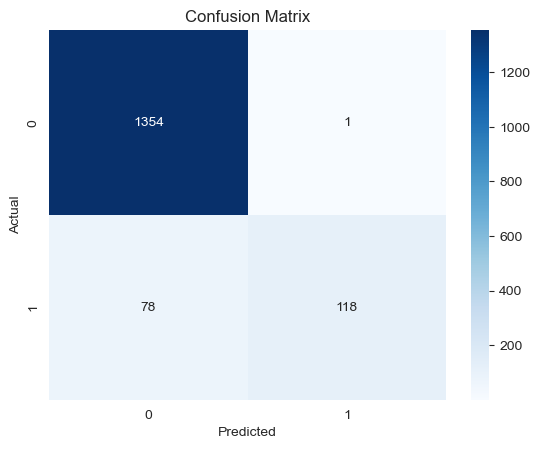

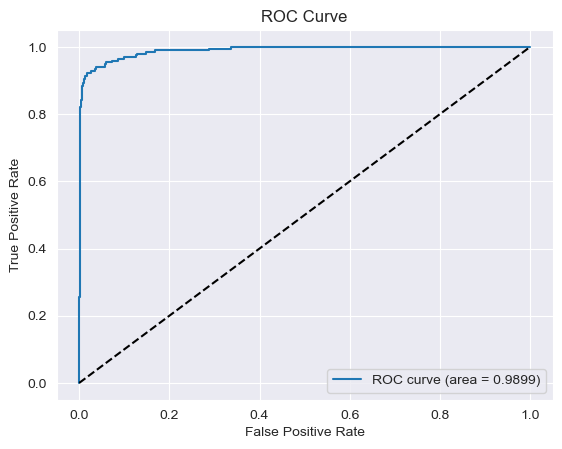

In [143]:
evaluate_model(log_model, test_x, test_y)

### **Оценка модели SVM**

Accuracy: 0.9819


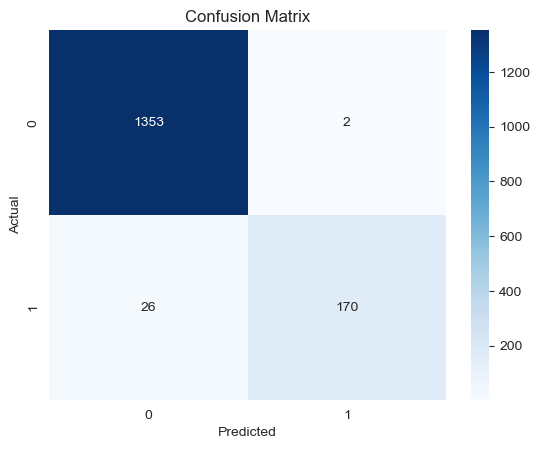

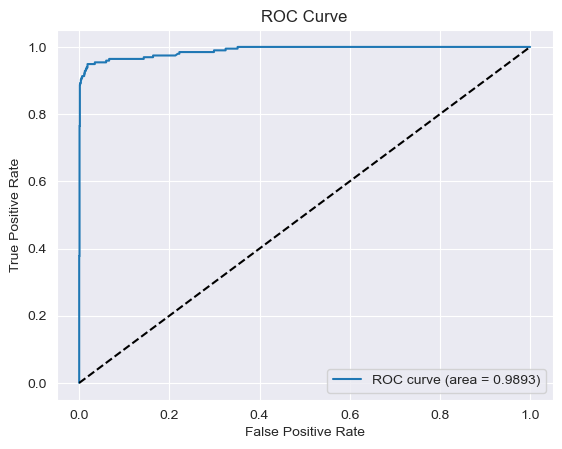

In [144]:
evaluate_model(svm_model, test_x, test_y)

### **Оценка модели Случайного Леса**

Accuracy: 0.9729


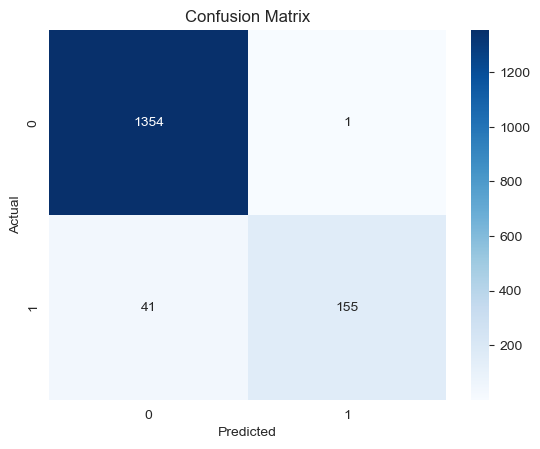

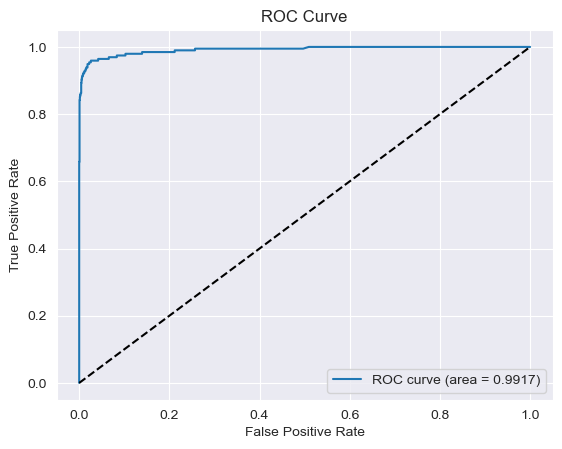

In [145]:
evaluate_model(rf_model, test_x, test_y)

### **Оценка модели Градиентного Бустинга**

Accuracy: 0.9678


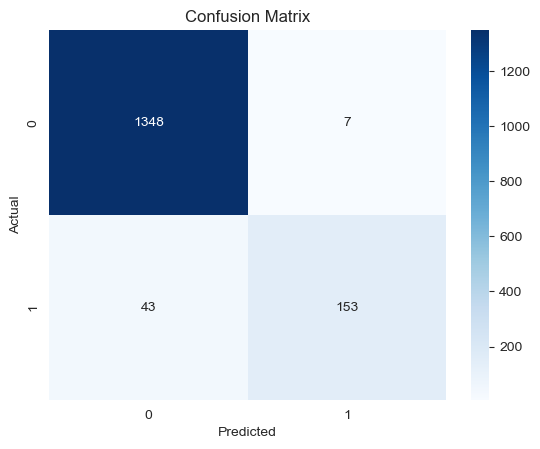

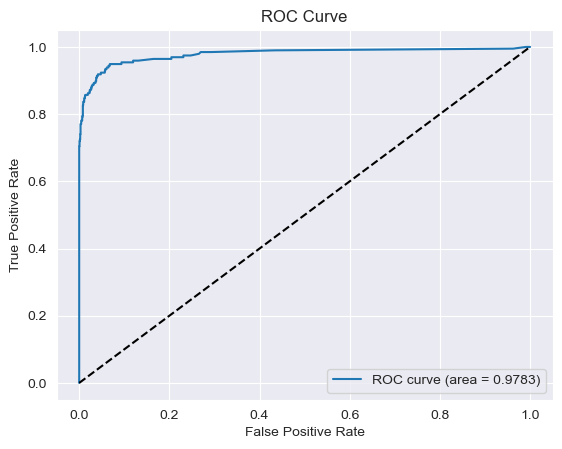

In [146]:
evaluate_model(gb_model, test_x, test_y)

#### Исходя из полученных результатов, мы можем сделать вывод, что наилучшей моделью в данном случае оказалась SVM. Она имеет наименьшее количество false-negative результатов, когда спам-письмо ложно определяется как не спам.

### **Автоматический отбор гиперпараметров при помощи _GridSearchCV_, _RandomizedSearchCV_**

#### **(Grid/Randomized)SearchCV** - это утилиты из sklearn, позволяющие автоматически отобрать гиперпараметры для модели, проводя кросс-валидацию и делающие вывод на основе указанной метрики.
#### **GridSearchCV** перебирает все возможные комбинации гиперпараметров из указанной "сетки", и используется в том случае, кода у нас не слишком большое количество данных, или доступны достаточные вычислительные мощности.
#### **RandomizedSearchCV** быстрее чем GridSearch, т.к. случайно выбирает гиперпараметры из предоставленного списка, проходя лишь через указанное количество итераций. Пускай его точность не настолько весома, как в случае GridSearchCV, он позволяет работать со сложными моделями, а также лучше спрвляется с подбором непрерывных гиперпараметров вроде learning_rate.  

#### В качестве метрики для оценки будем использовать _f1 score_, конкретнее _f1_macro_, так как он учитывает влияние всех классов, и лучше всего подходит для нашего случая: несбалансированность классов при большей важности класса-меньшинства.

https://scikit-learn.org/stable/modules/grid_search.html

### **Подбор гиперпараметров для Случайного Леса**
#### Случайный Лес имеет следующие весомые гиперпараметры:
* **n_estimators**: количество деревьев
* **max_depth**: глубина деревьев
* **min_samples_split**: минимальное количество выборок, необходимых для разделения узла.

In [147]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)
grid_search.fit(train_x, train_y)

print(f"Лучшие параметры: {grid_search.best_params_}")
print(f"Лучшая метрика: {grid_search.best_score_:.4f}")

Лучшие параметры: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
Лучшая метрика: 0.9313


### **Подбор гиперпараметров для SVM**
#### SVM имеет следующие весомые гиперпараметры:
* **C**: параметр регуляризации. Чем больше значение, тем меньше регуляризация.
* **kernel**: тип ядра
* **gamma**: коэффициент ядра для 'rbf', 'poly', 'sigmoid'. Определяет, насколько далеко влияют отдельные точки данных.
* **degree**: степень полинома для ядра 'poly'

In [148]:
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto'],
    'degree': [2, 3, 4]
}

grid_search = GridSearchCV(
    SVC(probability=True, random_state=42),
    param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)
grid_search.fit(train_x, train_y)

print(f"Лучшие параметры: {grid_search.best_params_}")
print(f"Лучшая метрика: {grid_search.best_score_:.4f}")

Лучшие параметры: {'C': 10, 'degree': 2, 'gamma': 'scale', 'kernel': 'linear'}
Лучшая метрика: 0.9500


### **Подбор гиперпараметров для Градиентного Бустинга**
#### Градиентный Бустинг имеет следующие весомые гиперпараметры:
* **n_estimators**: Количество деревьев.
* **learning_rate**: Скорость обучения. Меньшее значение требует больше деревьев.
* **max_depth**: Максимальная глубина деревьев.
* **min_samples_split**: Минимальное количество выборок, необходимых для разделения узла.
* **subsample**: Доля выборок, используемых для обучения каждого дерева (меньше 1.0 помогает избежать переобучения).

In [149]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

param_distributions = {
    'n_estimators': randint(50, 200),
    'learning_rate': uniform(0.01, 0.2),
    'max_depth': randint(3, 10),
    'min_samples_split': randint(2, 10),
    'subsample': uniform(0.8, 0.2)
}

grid_search = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_distributions,
    n_iter=20,
    cv=5,
    scoring='f1_macro',
    random_state=42,
    n_jobs=-1
)
grid_search.fit(train_x, train_y)

print(f"Лучшие параметры: {grid_search.best_params_}")
print(f"Лучшая метрика: {grid_search.best_score_:.4f}")

Лучшие параметры: {'learning_rate': 0.08708330050798323, 'max_depth': 4, 'min_samples_split': 6, 'n_estimators': 179, 'subsample': 0.9368466053024315}
Лучшая метрика: 0.9319


#### Мы смогли подобрать необходимые параметры для моделей. Пускай результаты изначальной работы моделей не отображены в отчёте, можно утверждать, что производительность моделей в общем повысилась, особенно после смены метрики для поиска гиперпараметров на подходящий f1_macro

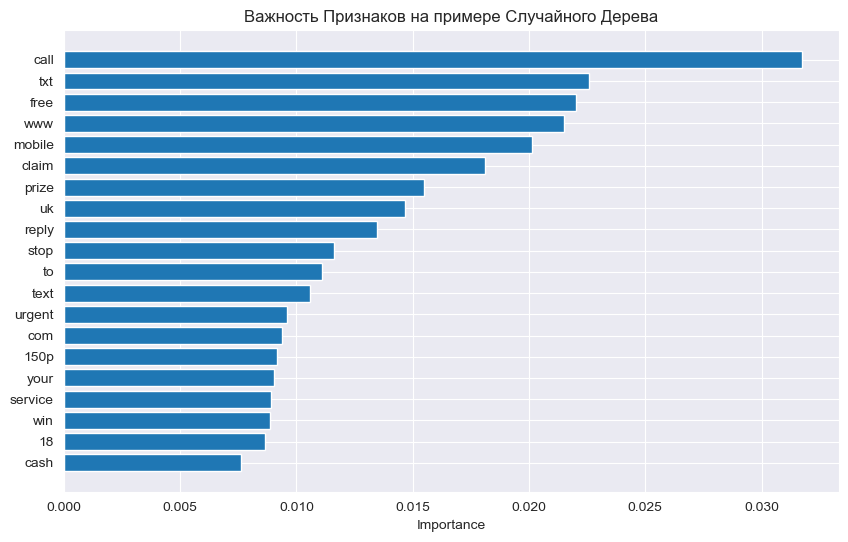

In [150]:
feature_importances = rf_model.feature_importances_
top_n = 20
indices = np.argsort(feature_importances)[-top_n:]

plt.figure(figsize=(10, 6))
plt.title("Важность Признаков на примере Случайного Дерева")
plt.barh(range(len(indices)), feature_importances[indices], align="center")
plt.yticks(range(len(indices)), [vectorizer.get_feature_names_out()[i] for i in indices])
plt.xlabel("Importance")
plt.show()

### **Итог**:
#### В этой работе мы использовали несколько разнообразных моделей для классификации и сравнили их производительность. Также мы смогли подобрать необходимые гиперпараметры, улучшив производительность ещё сильнее.